# ML CRYPTOGRAPHY PROJECT

In [1]:
# 1] Importing python libraries 
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# 2] Loading and fetching data from CSV dataset
df=pd.read_csv("dataset.csv")
df.head(10)

,sr.no,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,05-05-2013
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,05-05-2013
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,06-05-2013
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,06-05-2013
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,07-05-2013
5,5,3.370870,3.406720,2.939790,3.332740,0.0,5.805127e+07,2013-05-07T23:59:59.999Z,Litecoin,07-05-2013
6,6,3.283620,3.491120,3.283620,3.409240,0.0,5.950822e+07,2013-05-08T23:59:59.999Z,Litecoin,08-05-2013
7,7,109.599998,115.779999,109.599998,113.566002,0.0,1.264049e+09,2013-05-08T23:59:59.999Z,Bitcoin,08-05-2013
8,8,3.399400,3.441690,3.294850,3.416150,0.0,5.975557e+07,2013-05-09T23:59:59.999Z,Litecoin,09-05-2013
9,9,113.199997,113.459999,109.260002,112.669998,0.0,1.254535e+09,2013-05-09T23:59:59.999Z,Bitcoin,09-05-2013


In [3]:
df.columns


Index(['sr.no', 'open', 'high', 'low', 'close', 'volume', 'marketCap',
       'timestamp', 'crypto_name', 'date'],
      dtype='object')

In [4]:
df.shape


(72946, 10)

In [5]:
df.dtypes


sr.no            int64
open           float64
high           float64
low            float64
close          float64
volume         float64
marketCap      float64
timestamp       object
crypto_name     object
date            object
dtype: object

In [6]:
df.isnull().sum()

sr.no          0
open           0
high           0
low            0
close          0
volume         0
marketCap      0
timestamp      0
crypto_name    0
date           0
dtype: int64

In [7]:
#3] DATA Collection  
#creating and gathering data from df to another df 
crypdf = df[['open', 'high', 'low', 'close', 'volume', 'marketCap']].copy()

In [8]:
crypdf

,open,high,low,close,volume,marketCap
0,112.900002,118.800003,107.142998,115.910004,0.000000e+00,1.288693e+09
1,3.493130,3.692460,3.346060,3.590890,0.000000e+00,6.229819e+07
2,115.980003,124.663002,106.639999,112.300003,0.000000e+00,1.249023e+09
3,3.594220,3.781020,3.116020,3.371250,0.000000e+00,5.859436e+07
4,112.250000,113.444000,97.699997,111.500000,0.000000e+00,1.240594e+09
...,...,...,...,...,...,...
72941,0.022604,0.022988,0.022197,0.022796,4.040134e+07,1.652957e+09
72942,1.468244,1.530464,1.435415,1.517878,2.844351e+07,1.572825e+09
72943,4.950431,5.148565,4.945280,5.117206,1.069497e+08,1.559551e+09
72944,0.000233,0.000243,0.000226,0.000239,2.143268e+08,1.576291e+09


In [9]:
crypdf.shape

(72946, 6)

In [10]:
#4) Data Preparation 
#I)Handling missing values 
print(df.isnull().sum()) 
#II)Clean Data
crypdf = crypdf.drop_duplicates()
crypdf.columns = crypdf.columns.str.strip()

sr.no          0
open           0
high           0
low            0
close          0
volume         0
marketCap      0
timestamp      0
crypto_name    0
date           0
dtype: int64


In [11]:
crypdf.head()

,open,high,low,close,volume,marketCap
0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09
1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07
2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09
3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07
4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09


In [12]:
crypdf.shape

(72896, 6)

In [13]:
# III]Scaling data
from sklearn.preprocessing import MinMaxScaler

crypdf = crypdf.copy()

scaler = MinMaxScaler()
numerical_cols = crypdf.select_dtypes(include=['float64', 'int64']).columns

crypdf[numerical_cols] = scaler.fit_transform(crypdf[numerical_cols])

In [14]:
crypdf

,open,high,low,close,volume,marketCap
0,1.671361e-03,7.324822e-04,1.612174e-03,1.715487e-03,0.000000,0.001015
1,5.171197e-05,2.276651e-05,5.034794e-05,5.314575e-05,0.000000,0.000049
2,1.716957e-03,7.686315e-04,1.604605e-03,1.662058e-03,0.000000,0.000983
3,5.320850e-05,2.331254e-05,4.688655e-05,4.989504e-05,0.000000,0.000046
4,1.661739e-03,6.994588e-04,1.470085e-03,1.650218e-03,0.000000,0.000977
...,...,...,...,...,...,...
72941,3.346242e-07,1.417348e-07,3.339930e-07,3.373831e-07,0.000115,0.001302
72942,2.173574e-05,9.436346e-06,2.159860e-05,2.246484e-05,0.000081,0.001238
72943,7.328571e-05,3.174438e-05,7.441130e-05,7.573548e-05,0.000305,0.001228
72944,3.443019e-09,1.497981e-09,3.399539e-09,3.540197e-09,0.000611,0.001241


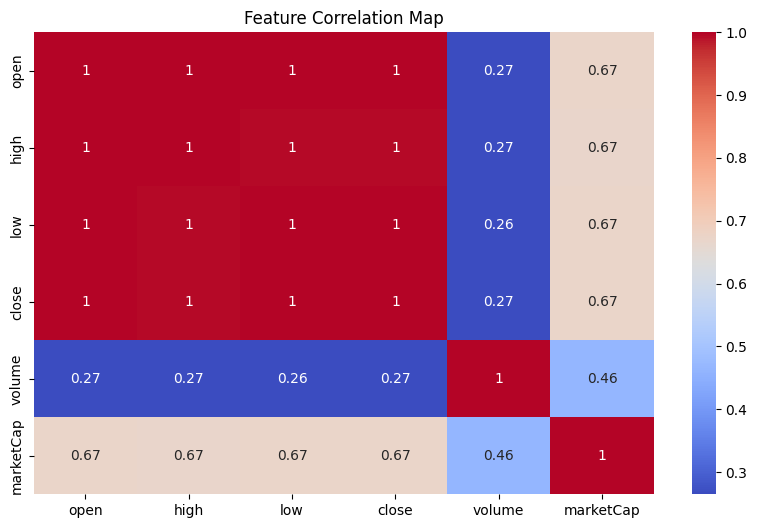

In [15]:
# 5]EDA 

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crypdf.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Map")
plt.show()

<Axes: title={'center': 'Normalized Close Price Trend'}>

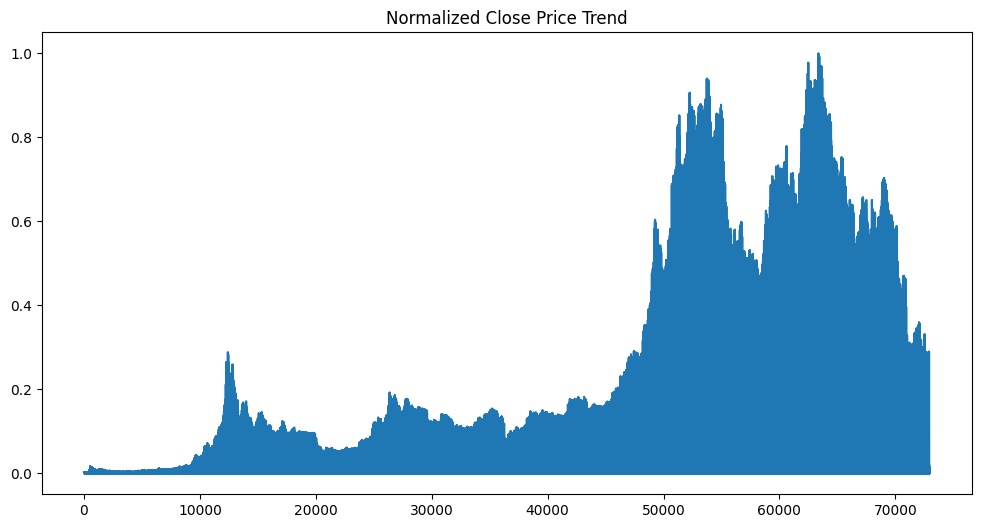

In [16]:
# Visualize Close Price Trend
crypdf['close'].plot(figsize=(12, 6), title="Normalized Close Price Trend")

In [17]:
## 6] Feature Engineering 
##A)
import numpy as np

df['rolling_vol'] = df['close'].pct_change().rolling(window=7).std()

df['MA_20'] = df['close'].rolling(window=20).mean()
df['liquidity_ratio'] = df['volume'] / df['marketCap']

df['upper_band'] = df['MA_20'] + (df['close'].rolling(window=20).std() * 2)
df['lower_band'] = df['MA_20'] - (df['close'].rolling(window=20).std() * 2)

df.dropna(inplace=True) # Remove rows with NaN from rolling windows

In [18]:
## B)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Replaced infinite values with NaN and drops all NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['open', 'high', 'low', 'volume', 'MA_20', 'liquidity_ratio', 'rolling_vol'], inplace=True)

# Features and Target
X = df[['open', 'high', 'low', 'volume', 'MA_20', 'liquidity_ratio']]
y = df['rolling_vol']

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100) # MODEL CREATION
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
## 7]Model Evaluation 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

predictions = model.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}")
print(f"MAE: {mean_absolute_error(y_test, predictions)}")
print(f"R2 Score: {r2_score(y_test, predictions)}")

RMSE: 1282361151972.9443
MAE: 66632658203.63212
R2 Score: 0.26497823020669575


In [20]:
# 8] .pkl FILE FOR APP.PY 
import joblib
joblib.dump(model, 'volatility_model.pkl')

['volatility_model.pkl']

In [21]:
## HERE WE ARE USING THE .pkl so used "default" settings (like n_estimators=100). but for other term we can use gridsearchCV for future model 

# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5]
# }

# grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2')
# grid_search.fit(X_train, y_train)

# best_model = grid_search.best_estimator_
# joblib.dump(best_model, 'volatility_model.pkl') # Save for deployment